2025-10-14 02:27:34.329369: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-14 02:27:34.372752: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-14 02:27:34.372787: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-14 02:27:34.373859: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-14 02:27:34.380068: I tensorflow/core/platform/cpu_feature_guar

⚠ No GPU detected — running on CPU (slower).
✅ Found and trimmed 3064 image-mask pairs correctly matched.
✅ Split -> Train: 2139, Val: 312, Test: 613


2025-10-14 02:27:42.160901: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/nfsshare/users/kamali/.conda/envs/myenv/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_1525276/1993906580.py:64: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.3),


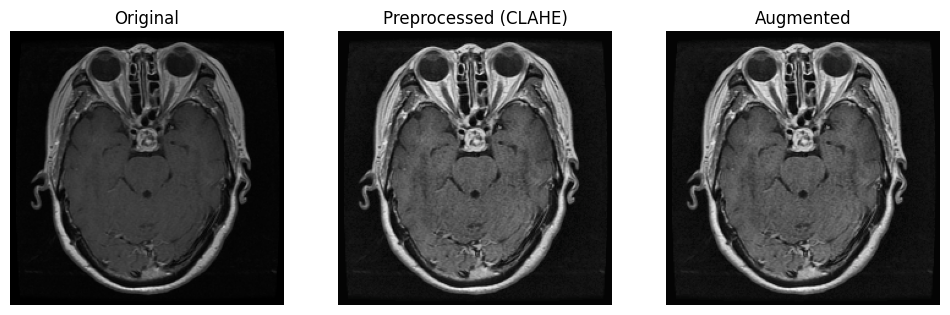

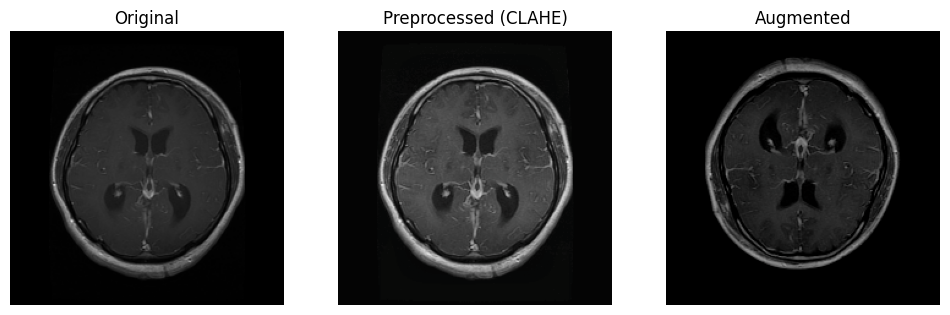

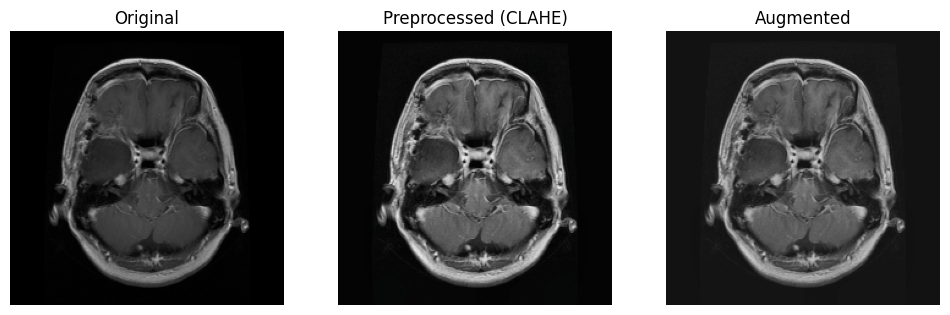


🚀 Training Enhanced_UNet_P6 for 100 epochs...
Epoch 1/100
    268/Unknown - 96s 316ms/step - loss: 0.8103 - dice_coef: 0.0362 - accuracy: 0.7043
Epoch 1: val_dice_coef improved from -inf to 0.03503, saving model to saved_models/Enhanced_UNet_P6/best_model.h5


/nfsshare/users/kamali/.conda/envs/myenv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


268/268 [==============================] - 104s 348ms/step - loss: 0.8103 - dice_coef: 0.0362 - accuracy: 0.7043 - val_loss: 0.8038 - val_dice_coef: 0.0350 - val_accuracy: 0.6900 - lr: 1.0000e-04
Epoch 2/100
268/268 [==============================] - ETA: 0s - loss: 0.7439 - dice_coef: 0.0415 - accuracy: 0.9191
Epoch 2: val_dice_coef improved from 0.03503 to 0.04859, saving model to saved_models/Enhanced_UNet_P6/best_model.h5
268/268 [==============================] - 84s 314ms/step - loss: 0.7439 - dice_coef: 0.0415 - accuracy: 0.9191 - val_loss: 0.6806 - val_dice_coef: 0.0486 - val_accuracy: 0.9842 - lr: 1.0000e-04
Epoch 3/100
268/268 [==============================] - ETA: 0s - loss: 0.6804 - dice_coef: 0.0571 - accuracy: 0.9646
Epoch 3: val_dice_coef improved from 0.04859 to 0.07766, saving model to saved_models/Enhanced_UNet_P6/best_model.h5
268/268 [==============================] - 84s 313ms/step - loss: 0.6804 - dice_coef: 0.0571 - accuracy: 0.9646 - val_loss: 0.6293 - val_dice

In [1]:
# =============================================
# FULL: full_colab_pipeline_autotrim.py
# =============================================
import os, random, cv2, glob
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, mixed_precision
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from skimage import morphology
import albumentations as A
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ---------------- CONFIG ----------------
DATA_ROOT = "./"  # 🔧 Set your dataset folder here
IMAGE_DIR = "images"
MASK_DIR  = "masks"

IMG_SIZE = (224, 224)
BATCH_SIZE = 8
SEED = 42
SAVE_DIR = "saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# ---------------- GPU + Mixed Precision ----------------
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
        mixed_precision.set_global_policy('mixed_float16')
        print("✅ GPU detected:", gpus)
        print("🔺 Mixed precision enabled for speed.")
    except Exception as e:
        print("⚠ GPU found but mixed precision not set:", e)
else:
    print("⚠ No GPU detected — running on CPU (slower).")

# ---------------- RANDOM SEED ----------------
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ---------------- METRICS & LOSS ----------------
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    inter = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * inter + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred): return 1.0 - dice_coef(y_true, y_pred)
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return 0.5 * bce + 0.5 * dice_loss(y_true, y_pred)

# ---------------- AUGMENTATION ----------------
aug_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.GaussianBlur(blur_limit=(3,7), p=0.3),
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.3),
    A.RandomBrightnessContrast(p=0.3)
])

# ---------------- PREPROCESS ----------------
def _apply_clahe_uint8(img_uint8):
    lab = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def preprocess_and_augment(img_path, mask_path, augment=True):
    img_bgr = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if img_bgr is None or mask is None:
        raise FileNotFoundError(f"Missing pair -> {img_path} | {mask_path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, IMG_SIZE)
    mask = cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)

    mask_bool = morphology.remove_small_objects(mask > 127, min_size=64)
    mask_bool = morphology.remove_small_holes(mask_bool, area_threshold=64)
    mask_uint8 = (mask_bool.astype(np.uint8) * 255)

    img_clahe = _apply_clahe_uint8(img_rgb)
    if augment:
        aug = aug_pipeline(image=img_clahe, mask=mask_uint8)
        img_clahe, mask_uint8 = aug['image'], aug['mask']

    img_out = img_clahe.astype(np.float32) / 255.0
    mask_out = np.expand_dims((mask_uint8 > 127).astype(np.float32), -1)
    return img_out, mask_out

# ---------------- VISUALIZATION ----------------
def visualize_preprocessing_examples(img_paths, mask_paths, n=3):
    n = min(n, len(img_paths))
    for i in range(n):
        ip, mp = img_paths[i], mask_paths[i]
        orig = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
        orig = cv2.resize(orig, IMG_SIZE)
        prep_img, prep_mask = preprocess_and_augment(ip, mp, augment=False)
        aug_img, aug_mask = preprocess_and_augment(ip, mp, augment=True)

        fig, axs = plt.subplots(1,3,figsize=(12,4))
        axs[0].imshow(orig); axs[0].set_title("Original"); axs[0].axis('off')
        axs[1].imshow(np.clip(prep_img,0,1)); axs[1].set_title("Preprocessed (CLAHE)"); axs[1].axis('off')
        axs[2].imshow(np.clip(aug_img,0,1)); axs[2].set_title("Augmented"); axs[2].axis('off')
        plt.show()

# ---------------- LOAD & AUTO-TRIM DATA ----------------
img_files = sorted(os.listdir(IMAGE_DIR))
mask_files = sorted(os.listdir(MASK_DIR))

# Keep only files that exist in both folders
img_set = set(img_files)
mask_set = set(mask_files)
common_files = sorted(list(img_set & mask_set))

if len(common_files) < 3064:
    raise RuntimeError(f"❌ Only {len(common_files)} matched pairs found. Need full dataset of 3064 pairs.")

# Trim to exactly 3064
common_files = common_files[:3064]

img_paths = [os.path.join(IMAGE_DIR, f) for f in common_files]
mask_paths = [os.path.join(MASK_DIR, f) for f in common_files]

print(f"✅ Found and trimmed {len(img_paths)} image-mask pairs correctly matched.")

# ---------------- SHUFFLE & SPLIT ----------------
indices = np.arange(len(img_paths))
np.random.seed(SEED)
np.random.shuffle(indices)
img_paths = np.array(img_paths)[indices]
mask_paths = np.array(mask_paths)[indices]

train_imgs, test_imgs, train_masks, test_masks = train_test_split(img_paths, mask_paths, test_size=0.2, random_state=SEED)
train_imgs, val_imgs, train_masks, val_masks = train_test_split(train_imgs, train_masks, test_size=307/2415, random_state=SEED)

print(f"✅ Split -> Train: {len(train_imgs)}, Val: {len(val_imgs)}, Test: {len(test_imgs)}")

# Visualize preprocessing examples
visualize_preprocessing_examples(train_imgs.tolist(), train_masks.tolist(), n=3)

# ---------------- TF DATASET ----------------
def generator_fn(img_list, mask_list, augment=False):
    for ip, mp in zip(img_list, mask_list):
        yield preprocess_and_augment(ip, mp, augment)

def make_tf_dataset(img_list, mask_list, augment=False):
    out_sig = (
        tf.TensorSpec(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), dtype=tf.float32),
        tf.TensorSpec(shape=(IMG_SIZE[0], IMG_SIZE[1], 1), dtype=tf.float32)
    )
    ds = tf.data.Dataset.from_generator(lambda: generator_fn(img_list, mask_list, augment),
                                        output_signature=out_sig)
    if augment:
        ds = ds.shuffle(512, seed=SEED)

    # -------------------- NEW --------------------
    ds = ds.map(lambda x, y: (x, y), num_parallel_calls=tf.data.AUTOTUNE)  # parallel preprocessing
    ds = ds.cache()  # cache in memory
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    # ---------------------------------------------

    return ds


train_ds = make_tf_dataset(train_imgs.tolist(), train_masks.tolist(), augment=True)
val_ds   = make_tf_dataset(val_imgs.tolist(), val_masks.tolist(), augment=False)
test_ds  = make_tf_dataset(test_imgs.tolist(), test_masks.tolist(), augment=False)


# ---------------- MODEL BUILDERS ----------------
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    return x

def encoder_block(x, filters):
    c = conv_block(x, filters)
    p = layers.MaxPooling2D((2,2))(c)
    return c, p

def decoder_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
    x = layers.Concatenate()([x, skip])
    return conv_block(x, filters)

def build_unet(input_shape=(224,224,3), base_filters=32):
    inputs = layers.Input(shape=input_shape)
    c1,p1 = encoder_block(inputs, base_filters)
    c2,p2 = encoder_block(p1, base_filters*2)
    c3,p3 = encoder_block(p2, base_filters*4)
    c4,p4 = encoder_block(p3, base_filters*8)
    b = conv_block(p4, base_filters*16)
    d1 = decoder_block(b, c4, base_filters*8)
    d2 = decoder_block(d1, c3, base_filters*4)
    d3 = decoder_block(d2, c2, base_filters*2)
    d4 = decoder_block(d3, c1, base_filters)
    out = layers.Conv2D(1,1,activation='sigmoid', dtype='float32')(d4)
    return models.Model(inputs, out, name="U-Net")

from tensorflow.keras.applications import ResNet50, MobileNetV2

def build_resnet_unet(input_shape=(224,224,3)):
    base = ResNet50(weights=None, include_top=False, input_shape=input_shape)
    skips = [base.get_layer(n).output for n in ['conv1_relu','conv2_block3_out','conv3_block4_out','conv4_block6_out']]
    x = base.output
    d1 = decoder_block(x, skips[-1], 512)
    d2 = decoder_block(d1, skips[-2], 256)
    d3 = decoder_block(d2, skips[-3], 128)
    d4 = decoder_block(d3, skips[-4], 64)
    out = layers.Conv2D(1,1,activation='sigmoid', dtype='float32')(d4)
    out = layers.UpSampling2D(size=(2,2),interpolation='bilinear')(out)
    return models.Model(base.input, out, name="ResNet_UNet")

def build_mobilenet_unet(input_shape=(224,224,3)):
    base = MobileNetV2(weights=None, include_top=False, input_shape=input_shape)
    skips = [base.get_layer(n).output for n in ['block_1_expand_relu','block_3_expand_relu','block_6_expand_relu','block_13_expand_relu']]
    x = base.output
    d1 = decoder_block(x, skips[-1], 256)
    d2 = decoder_block(d1, skips[-2], 128)
    d3 = decoder_block(d2, skips[-3], 64)
    d4 = decoder_block(d3, skips[-4], 32)
    out = layers.Conv2D(1,1,activation='sigmoid', dtype='float32')(d4)
    out = layers.UpSampling2D(size=(2,2),interpolation='bilinear')(out)
    return models.Model(base.input, out, name="MobileNet_UNet")

def build_enhanced_unet(input_shape=(224,224,3), base_filters=32, dropout=0.3):
    inputs = layers.Input(shape=input_shape)
    skips=[]
    x=inputs
    for i in range(5):
        f = base_filters*(2**i)
        c = conv_block(x, f)
        skips.append(c)
        x = layers.MaxPooling2D(2)(c)
    b = conv_block(x, base_filters*(2**5))
    b = layers.Dropout(dropout)(b)
    for i in reversed(range(5)):
        f = base_filters*(2**i)
        b = decoder_block(b, skips[i], f)
    out = layers.Conv2D(1,1,activation='sigmoid', dtype='float32')(b)
    return models.Model(inputs, out, name="Enhanced_UNet_P6")

# ---------------- TRAIN ----------------
def compile_model(model):
    model.compile(optimizer=RMSprop(1e-4),
                  loss=bce_dice_loss,
                  metrics=[dice_coef, tf.keras.metrics.BinaryAccuracy(name='accuracy')])
    return model

def train_and_save_model(model, train_ds, val_ds, epochs_override=None):
    ckpt_dir = os.path.join(SAVE_DIR, model.name)
    os.makedirs(ckpt_dir, exist_ok=True)
    ckpt_path = os.path.join(ckpt_dir, "best_model.h5")

    ckpt = ModelCheckpoint(ckpt_path, monitor='val_dice_coef', save_best_only=True, mode='max', verbose=1)
    reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, verbose=1)
    early  = EarlyStopping(monitor='val_dice_coef', patience=15, mode='max', restore_best_weights=True, verbose=1)

    compile_model(model)
    epochs_run = 70 if epochs_override is None else int(epochs_override)

    print(f"\n🚀 Training {model.name} for {epochs_run} epochs...")
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs_run, callbacks=[ckpt, reduce, early])
    print(f"✅ {model.name} finished. Best saved at {ckpt_path}")
    return hist

# ---------------- RUN MODELS ----------------
models_epochs = [
    (build_enhanced_unet(), 100),
    (build_unet(), 30),
    (build_resnet_unet(), 30),
    (build_mobilenet_unet(), 30)
]

for m, ep in models_epochs:
    train_and_save_model(m, train_ds, val_ds, epochs_override=ep)

# ---------------- FINAL PERFORMANCE SUMMARY ----------------
from tensorflow.keras.models import load_model
summary=[]
model_names=["Enhanced_UNet_P6","U-Net","ResNet_UNet","MobileNet_UNet"]

for name in model_names:
    path=os.path.join(SAVE_DIR,name,"best_model.h5")
    if not os.path.exists(path): continue
    model=load_model(path, compile=False)
    model.compile(optimizer=RMSprop(1e-4), loss=bce_dice_loss, metrics=[dice_coef, tf.keras.metrics.BinaryAccuracy(name='accuracy')])
    res=model.evaluate(test_ds,verbose=0)
    summary.append((name,res[1]*100,res[2]*100))

print("\n📊 Final Test Performance Summary:")
print("{:<20} {:<12} {:<12}".format("Model","Dice %","Accuracy %"))
print("-"*46)
for n,d,a in summary:
    print("{:<20} {:<12.2f} {:<12.2f}".format(n,d,a))

✅ Loaded Enhanced_UNet_P6
✅ Loaded U-Net
✅ Loaded ResNet_UNet
✅ Loaded MobileNet_UNet
1/1 [==============================] - 1s 1s/step
Enhanced_UNet_P6: Dice=8.34%, Accuracy=69.39%
1/1 [==============================] - 1s 566ms/step
U-Net: Dice=93.17%, Accuracy=99.81%
1/1 [==============================] - 2s 2s/step
ResNet_UNet: Dice=85.22%, Accuracy=99.55%
1/1 [==============================] - 2s 2s/step
MobileNet_UNet: Dice=2.66%, Accuracy=98.60%

📊 Model Comparison Table:
Model                Dice %       Accuracy %  
----------------------------------------------
Enhanced_UNet_P6     8.34         69.39       
U-Net                93.17        99.81       
ResNet_UNet          85.22        99.55       
MobileNet_UNet       2.66         98.60       
1/1 [==============================] - 0s 377ms/step


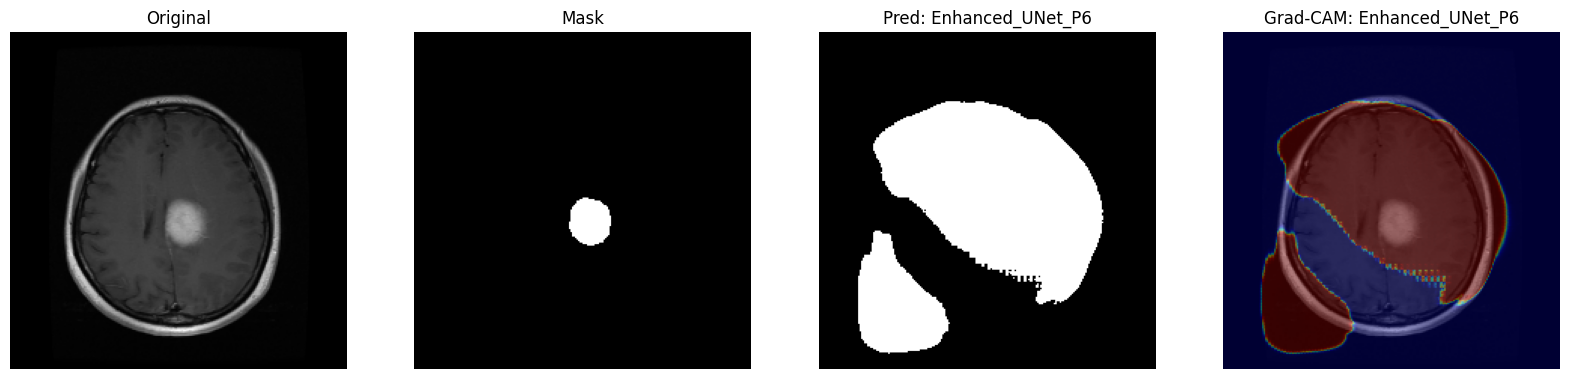

1/1 [==============================] - 0s 143ms/step


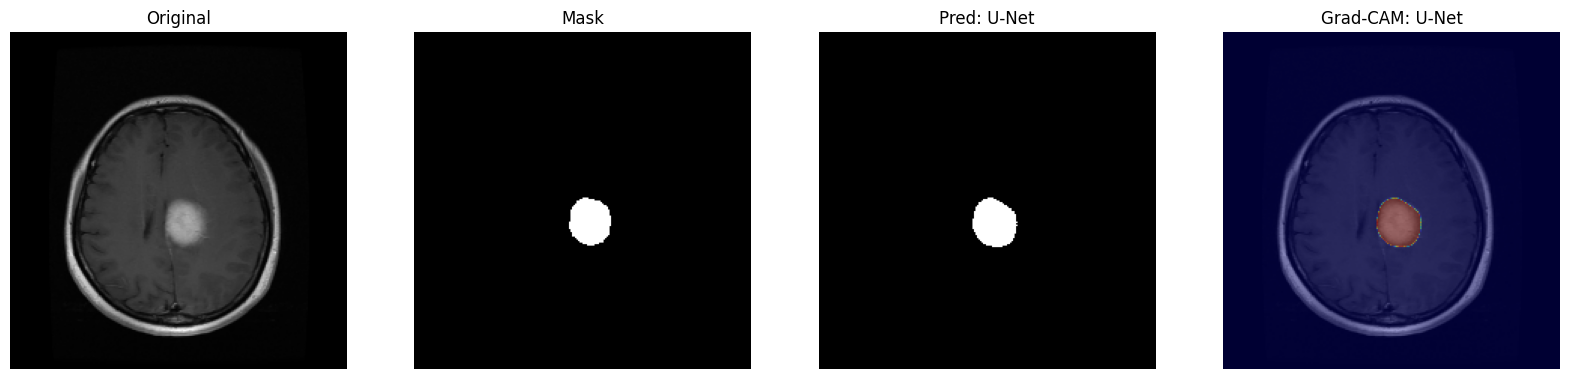

1/1 [==============================] - 0s 245ms/step


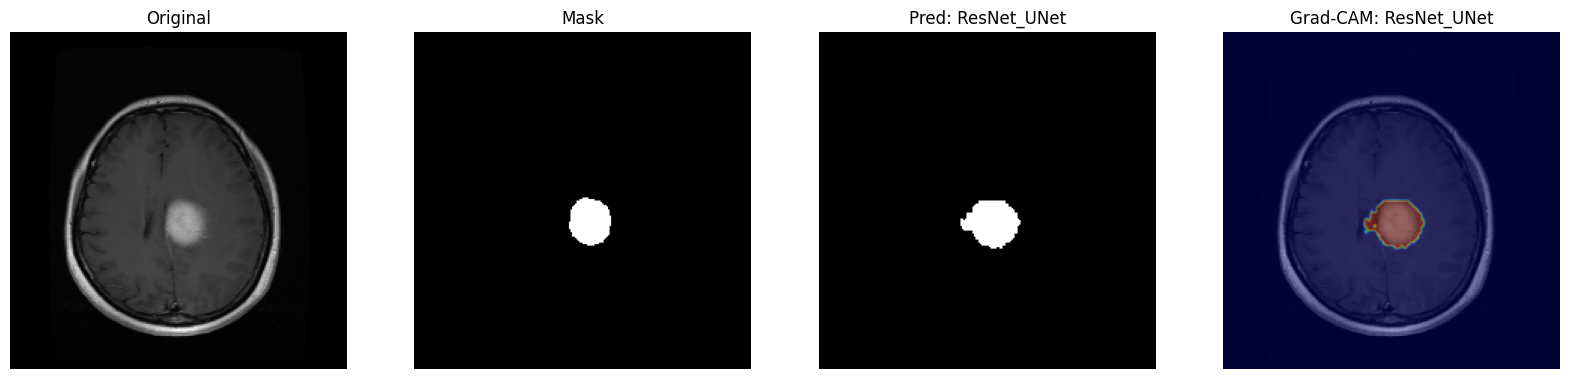

1/1 [==============================] - 0s 174ms/step


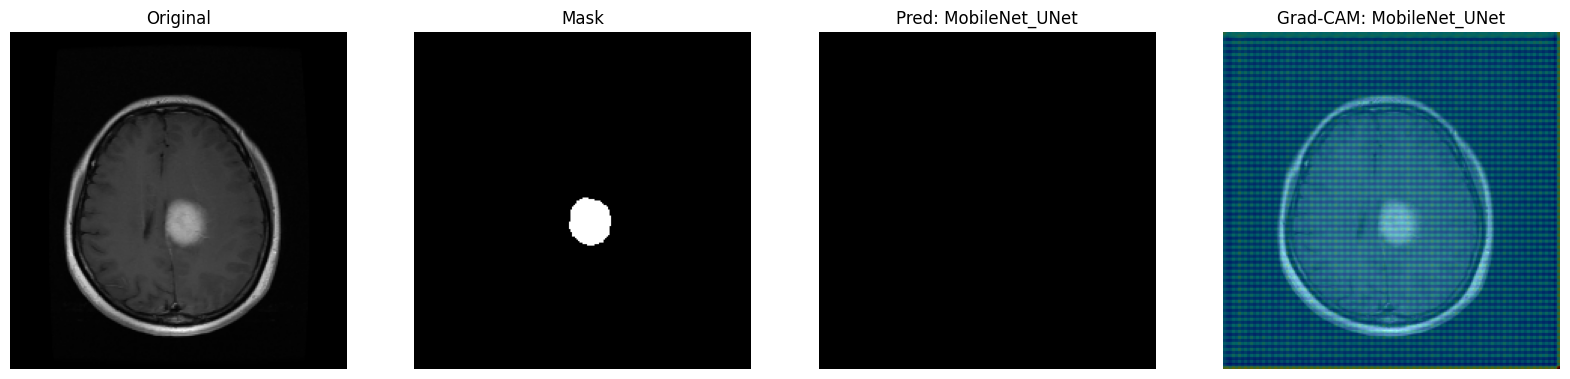

In [3]:
# =============================================
# TESTING + COMPARISON + GRADCAM VISUALIZATION
# =============================================
import os, cv2, numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import RMSprop

# ---------------- CONFIG ----------------
IMG_SIZE = (224,224)
SAVE_DIR = "saved_models"
SAMPLE_IMG_PATH = "images/10.png"  # 🔧 Replace with a sample image
SAMPLE_MASK_PATH = "masks/10.png"  # 🔧 Replace corresponding mask

# ---------------- LOSS + METRIC ----------------
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    inter = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * inter + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return 0.5*bce + 0.5*(1-dice_coef(y_true, y_pred))

# ---------------- PREPROCESS ----------------
def preprocess_image(img_path, mask_path=None):
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, IMG_SIZE)
    img_rgb = img_rgb.astype(np.float32)/255.0
    if mask_path:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, IMG_SIZE)
        mask = np.expand_dims((mask>127).astype(np.float32),-1)
        return np.expand_dims(img_rgb,0), np.expand_dims(mask,0)
    return np.expand_dims(img_rgb,0)

# ---------------- LOAD MODELS ----------------
model_names = ["Enhanced_UNet_P6","U-Net","ResNet_UNet","MobileNet_UNet"]
models_dict = {}
for name in model_names:
    path=os.path.join(SAVE_DIR,name,"best_model.h5")
    if os.path.exists(path):
        model = load_model(path, compile=False)
        model.compile(optimizer=RMSprop(1e-4), loss=bce_dice_loss,
                      metrics=[dice_coef, tf.keras.metrics.BinaryAccuracy(name='accuracy')])
        models_dict[name] = model
        print(f"✅ Loaded {name}")

# ---------------- PREDICTION & COMPARISON ----------------
img, mask = preprocess_image(SAMPLE_IMG_PATH, SAMPLE_MASK_PATH)

comparison_results=[]
for name, model in models_dict.items():
    pred = model.predict(img)
    dice = dice_coef(tf.convert_to_tensor(mask), tf.convert_to_tensor(pred)).numpy()*100
    acc = tf.keras.metrics.BinaryAccuracy()(mask, pred).numpy()*100
    comparison_results.append((name,dice,acc))
    print(f"{name}: Dice={dice:.2f}%, Accuracy={acc:.2f}%")

# ---------------- COMPARISON TABLE ----------------
print("\n📊 Model Comparison Table:")
print("{:<20} {:<12} {:<12}".format("Model","Dice %","Accuracy %"))
print("-"*46)
for n,d,a in comparison_results:
    print("{:<20} {:<12.2f} {:<12.2f}".format(n,d,a))

# ---------------- GRAD-CAM ----------------
def make_gradcam_heatmap(img_tensor, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = predictions[0]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = tf.maximum(heatmap,0)/tf.reduce_max(heatmap)
    return heatmap.numpy()

def superimpose_heatmap(img, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255*heatmap)
    heatmap = cv2.applyColorMap(heatmap, colormap)
    superimposed = cv2.addWeighted(cv2.cvtColor(np.uint8(img*255), cv2.COLOR_RGB2BGR),1-alpha,heatmap,alpha,0)
    return cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)

# ---------------- VISUALIZE SAMPLE WITH HEATMAP ----------------
for name, model in models_dict.items():
    last_conv_layer = None
    # pick last conv layer dynamically
    for l in reversed(model.layers):
        if isinstance(l, tf.keras.layers.Conv2D):
            last_conv_layer = l.name
            break
    heatmap = make_gradcam_heatmap(img, model, last_conv_layer)
    pred = model.predict(img)[0,:,:,0]
    superimposed = superimpose_heatmap(img[0], heatmap)
   
    fig, axs = plt.subplots(1,4,figsize=(20,5))
    axs[0].imshow(img[0]); axs[0].set_title("Original"); axs[0].axis('off')
    axs[1].imshow(mask[0,:,:,0], cmap='gray'); axs[1].set_title("Mask"); axs[1].axis('off')
    axs[2].imshow(pred>0.5, cmap='gray'); axs[2].set_title(f"Pred: {name}"); axs[2].axis('off')
    axs[3].imshow(superimposed); axs[3].set_title(f"Grad-CAM: {name}"); axs[3].axis('off')
    plt.show()